Provide an archive containing the report and the developed code to obtain the best performance on the full dataset provided:

1. BOW parameters should be tuned by you (image size, grid size, number of centroids, number of training images).
2. The maximum number of training images is 70, since the last 30 have to be used for testing
3. You can also experiment with a different classifier instead of the 1-NN provided, but it is more important to experiment with BOW parameters
4. Provide in the report the best parameter configuration obtained, the final accuracy, the confusion matrix, and a short comment about the type of classification errors that your model is doing

In [1]:
import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline

1. Load The Dataset

In [2]:
# Parameters
nClasses = 10                # number of classes
train_images = 70            # max allowed
test_images = 30

imsize = 256                 # image resize
grid_step = 8                # dense grid spacing
n_centroids = 200            # vocabulary size (K)
dataset_path = "../Datasets/image_orig/"


In [3]:
def dense_grid(imsize, step):
    xs = np.arange(step//2, imsize, step)
    ys = np.arange(step//2, imsize, step)
    return [(float(x), float(y)) for y in ys for x in xs]


In [4]:
# Extract SIFT features at dense grid locations
pointPositions = dense_grid(imsize, grid_step)
keypoints = [cv2.KeyPoint(x, y, 1) for x, y in pointPositions]

# Create SIFT feature extractor
sift = cv2.SIFT_create()

In [5]:
# Store image paths and labels for training and testing
train_paths = []
train_labels = []

test_paths = []
test_labels = []

for class_idx in range(nClasses):

    # training images
    for i in range(train_images):
        path = f"{dataset_path}/{100*class_idx + i}.jpg"
        train_paths.append(path)
        train_labels.append(class_idx)

    # testing images
    for i in range(train_images, train_images + test_images):
        path = f"{dataset_path}/{100*class_idx + i}.jpg"
        test_paths.append(path)
        test_labels.append(class_idx)



In [6]:
# Extract SIFT descriptors for all images
def extract_descriptors(image_paths):

    all_descriptors = []

    start = time.time()

    for path in image_paths:

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (imsize, imsize))

        _, descriptors = sift.compute(img, keypoints)

        all_descriptors.append(descriptors)

    print("Extraction time:", time.time() - start)

    return all_descriptors

In [7]:
print("Extracting training descriptors...")
train_descriptors = extract_descriptors(train_paths)


# Stack all descriptors for KMeans
stacked_descriptors = np.vstack(train_descriptors)

print("Total descriptors:", stacked_descriptors.shape)

Extracting training descriptors...


[ WARN:0@16.399] global loadsave.cpp:278 findDecoder imread_('../Datasets/image_orig//0.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [8]:
print("Training KMeans vocabulary...")

kmeans = KMeans(n_clusters=n_centroids, random_state=42, verbose=2)

kmeans.fit(stacked_descriptors)

Training KMeans vocabulary...
Initialization complete
Iteration 0, inertia 58846289920.0.
Iteration 1, inertia 45246996480.0.
Iteration 2, inertia 44467077120.0.
Iteration 3, inertia 44120854528.0.
Iteration 4, inertia 43913150464.0.
Iteration 5, inertia 43771330560.0.
Iteration 6, inertia 43667693568.0.
Iteration 7, inertia 43588923392.0.
Iteration 8, inertia 43527872512.0.
Iteration 9, inertia 43478450176.0.
Iteration 10, inertia 43438333952.0.
Iteration 11, inertia 43403702272.0.
Iteration 12, inertia 43374379008.0.
Iteration 13, inertia 43349434368.0.
Iteration 14, inertia 43327213568.0.
Iteration 15, inertia 43307589632.0.
Iteration 16, inertia 43289714688.0.
Iteration 17, inertia 43272617984.0.
Iteration 18, inertia 43256422400.0.
Iteration 19, inertia 43241680896.0.
Iteration 20, inertia 43228643328.0.
Iteration 21, inertia 43216814080.0.
Iteration 22, inertia 43205795840.0.
Iteration 23, inertia 43195580416.0.
Iteration 24, inertia 43185938432.0.
Iteration 25, inertia 431770091

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",200
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",2
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [9]:
def build_histograms(descriptor_list):

    histograms = []

    for descriptors in descriptor_list:

        words = kmeans.predict(descriptors)

        hist, _ = np.histogram(
            words,
            bins=np.arange(n_centroids + 1)
        )

        histograms.append(hist)

    return np.array(histograms)

In [21]:
print("Building training histograms...")
X_train = build_histograms(train_descriptors)

print("Extracting test descriptors...")
test_descriptors = extract_descriptors(test_paths)

print("Building test histograms...")
X_test = build_histograms(test_descriptors)


y_train = np.array(train_labels)
y_test = np.array(test_labels)

print("The shape of the training histograms:", X_train.shape)
print("The shape of the test histograms:", X_test.shape)


Building training histograms...
Extracting test descriptors...
Extraction time: 0.32452893257141113
Building test histograms...
The shape of the training histograms: (700, 200)
The shape of the test histograms: (300, 200)


In [11]:
# NORMALIZATION OF HISTOGRAMS
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# Defining the pipeline and parameter grid for GridSearchCV
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC())
])

param_grid = [

    # LinearSVC
    {
        'clf': [LinearSVC(max_iter=20000)],
        'clf__C': [0.1, 1, 10]
    },

    # LinearSVC L1
    {
        'clf': [LinearSVC(penalty='l1', dual=False, max_iter=20000)],
        'clf__C': [0.1, 1, 10]
    },

    # Linear Kernel SVC
    {
        'clf': [SVC(kernel='linear')],
        'clf__C': [0.1, 1, 10]
    },

    # RBF SVC
    {
        'clf': [SVC(kernel='rbf')],
        'clf__C': [0.1, 1, 10, 50],
        'clf__gamma': ['scale', 0.01, 0.001]
    },

    # Polynomial SVC
    {
        'clf': [SVC(kernel='poly')],
        'clf__C': [0.1, 1, 10],
        'clf__degree': [2, 3],
        'clf__gamma': ['scale', 0.01]
    },

    # NuSVC
    {
        'clf': [NuSVC()],
        'clf__nu': [0.1, 0.5],
        'clf__gamma': ['scale', 0.01]
    },

    # K-NN
    {
        'clf': [KNeighborsClassifier()],
        'clf__n_neighbors': [3, 5, 7]
    },

    # AdaBoost + SVM
    {
        'clf': [AdaBoostClassifier(
            estimator=SVC(probability=True)
        )],
        'clf__n_estimators': [50, 100]
    }
]



In [13]:
print("Running Grid Search with Cross Validation...")
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("\nBEST PARAMETERS:")
print(grid.best_params_)

print("BEST CROSS-VALIDATION ACCURACY:")
print(grid.best_score_)

best_clf = grid.best_estimator_

Running Grid Search with Cross Validation...
Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END ..........clf=LinearSVC(max_iter=20000), clf__C=0.1; total time=   0.1s
[CV] END ..........clf=LinearSVC(max_iter=20000), clf__C=0.1; total time=   0.1s
[CV] END ..........clf=LinearSVC(max_iter=20000), clf__C=0.1; total time=   0.2s
[CV] END ..........clf=LinearSVC(max_iter=20000), clf__C=0.1; total time=   0.2s
[CV] END ..........clf=LinearSVC(max_iter=20000), clf__C=0.1; total time=   0.2s
[CV] END ............clf=LinearSVC(max_iter=20000), clf__C=1; total time=   1.0s
[CV] END ............clf=LinearSVC(max_iter=20000), clf__C=1; total time=   0.9s
[CV] END ............clf=LinearSVC(max_iter=20000), clf__C=1; total time=   0.9s
[CV] END ............clf=LinearSVC(max_iter=20000), clf__C=1; total time=   1.0s
[CV] END clf=LinearSVC(dual=False, max_iter=20000, penalty='l1'), clf__C=0.1; total time=   0.1s
[CV] END clf=LinearSVC(dual=False, max_iter=20000, penalty='l1'), c

/Users/mulatyazewchekol/Documents/My_Projects/Supervised_Learning_Labs/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END clf=LinearSVC(dual=False, max_iter=20000, penalty='l1'), clf__C=10; total time=  16.8s
[CV] END clf=LinearSVC(dual=False, max_iter=20000, penalty='l1'), clf__C=10; total time=  16.6s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=50; total time=  14.1s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=50; total time=  14.1s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=50; total time=  14.4s


/Users/mulatyazewchekol/Documents/My_Projects/Supervised_Learning_Labs/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/mulatyazewchekol/Documents/My_Projects/Supervised_Learning_Labs/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END clf=LinearSVC(dual=False, max_iter=20000, penalty='l1'), clf__C=10; total time=  20.4s
[CV] END clf=LinearSVC(dual=False, max_iter=20000, penalty='l1'), clf__C=10; total time=  19.9s


/Users/mulatyazewchekol/Documents/My_Projects/Supervised_Learning_Labs/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END clf=LinearSVC(dual=False, max_iter=20000, penalty='l1'), clf__C=10; total time=  20.2s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=100; total time=  25.4s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=50; total time=  11.3s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=50; total time=  11.2s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=100; total time=  25.7s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=100; total time=  19.9s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=100; total time=  16.8s
[CV] END clf=AdaBoostClassifier(estimator=SVC(probability=True)), clf__n_estimators=100; total time=  16.7s

BEST PARAMETERS:
{'clf': SVC(), 'clf__C': 10, 'clf__gamma': 'scale'}
BEST CROSS-VALIDATION ACCURACY:
0.7671428571428571


In [14]:
# CLASSIFIER (BETTER THAN 1-NN)

print("Training classifier...")

clf = best_clf
clf.fit(X_train, y_train)

Training classifier...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'



FINAL ACCURACY: 0.7333333333333333

CONFUSION MATRIX:
[[16  3  0  1  0  1  2  2  2  3]
 [ 0 22  0  0  0  2  0  2  3  1]
 [ 0  5 16  3  0  0  0  2  3  1]
 [ 0  0  1 28  0  0  0  0  0  1]
 [ 0  0  0  0 30  0  0  0  0  0]
 [ 0  4  0  0  0 21  0  2  2  1]
 [ 5  1  0  0  0  0 20  0  2  2]
 [ 0  0  0  0  0  0  0 29  1  0]
 [ 3  7  1  1  0  2  0  1 14  1]
 [ 3  1  0  0  0  1  0  0  1 24]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.59      0.53      0.56        30
           1       0.51      0.73      0.60        30
           2       0.89      0.53      0.67        30
           3       0.85      0.93      0.89        30
           4       1.00      1.00      1.00        30
           5       0.78      0.70      0.74        30
           6       0.91      0.67      0.77        30
           7       0.76      0.97      0.85        30
           8       0.50      0.47      0.48        30
           9       0.71      0.80      0.75      

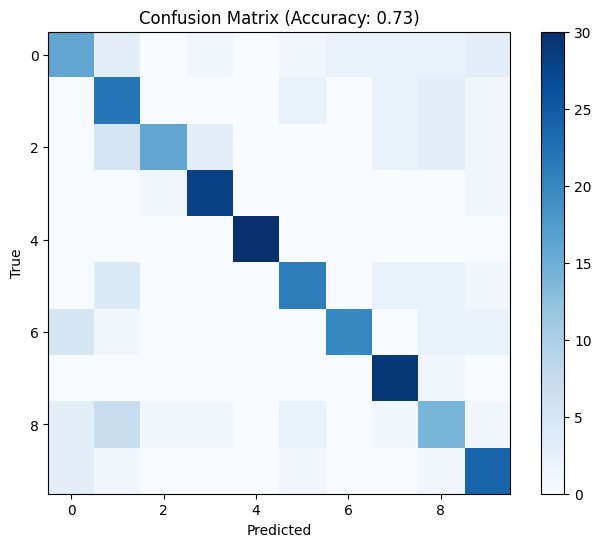

In [17]:
# EVALUATION

predictions = clf.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

print("\nFINAL ACCURACY:", accuracy)
print("\nCONFUSION MATRIX:")
print(cm)
report = classification_report(y_test, predictions)
print("\nCLASSIFICATION REPORT:")
print(report)
predicted_class = clf.predict(X_test)

print("Predictions:", predicted_class)


plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2f})')
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()